In [21]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')


try:
    from imblearn.over_sampling import SMOTE
    from sklearn.feature_extraction.text import TfidfVectorizer
    SMOTE_AVAILABLE = True
    print(' imbalanced-learn found — SMOTE will be used.')
except ImportError:
    SMOTE_AVAILABLE = False
    print('  imbalanced-learn not installed.')
    print('   Install with: pip install imbalanced-learn')
    print('   Falling back to Random Oversampling (same equal-class result).')

print('Libraries loaded ')

 imbalanced-learn found — SMOTE will be used.
Libraries loaded 


In [22]:

DATA_PATH = 'edufeed_clean_data.csv'  

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape : {df.shape}')
print(f'Columns       : {list(df.columns)}')
df.head(3)

Dataset shape : (19981, 62)
Columns       : ['professor_name', 'school_name', 'department_name', 'local_name', 'state_name', 'year_since_first_review', 'star_rating', 'take_again', 'diff_index', 'tag_professor', 'num_student', 'post_date', 'name_onlines', 'name_not_onlines', 'student_star', 'student_difficult', 'attence', 'for_credits', 'would_take_agains', 'grades', 'help_useful', 'help_not_useful', 'comments', 'word_comment', 'gender', 'race', 'asian', 'hispanic', 'nh_black', 'nh_white', 'gives_good_feedback', 'caring', 'respected', 'participation_matters', 'clear_grading_criteria', 'skip_class', 'amazing_lectures', 'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read', 'lots_of_homework', 'accessible_outside_class', 'lecture_heavy', 'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy', 'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline', 'post_year', 'post_month', 'date_missing_flag', 'grade_group', 'sentiment_label', 'help_ratio', 'difficulty_c

,professor_name,school_name,department_name,local_name,state_name,year_since_first_review,star_rating,take_again,diff_index,tag_professor,...,post_month,date_missing_flag,grade_group,sentiment_label,help_ratio,difficulty_category,experience_bucket,comment_length_cat,tag_count,course_mode
0,Leslie Looney,University Of Illinois At Urbana-Champaign,Astronomy Department,Champaign\Xe2\X80\X93Urbana,Il,11,4.7,0.75,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,6.0,0,B Range,Positive,0.0,Moderate,10+ yrs,Medium,3,Offline
1,Leslie Looney,University Of Illinois At Urbana-Champaign,Astronomy Department,Champaign\Xe2\X80\X93Urbana,Il,11,4.7,0.75,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,4.0,0,A Range,Positive,0.0,Easy,10+ yrs,Medium,3,Offline
2,Leslie Looney,University Of Illinois At Urbana-Champaign,Astronomy Department,Champaign\Xe2\X80\X93Urbana,Il,11,4.7,0.75,2.0,Hilarious (2) GROUP PROJECTS (2) Gives good ...,...,7.0,0,Not Reported,Positive,0.0,Moderate,10+ yrs,Medium,3,Offline


In [23]:
#  Inspect Target Column 
TARGET = 'sentiment_label'
TEXT_COL = 'comments'          # text column used if SMOTE path is taken

print('Class distribution BEFORE balancing:')
print('─' * 35)
counts_before = df[TARGET].value_counts()
print(counts_before.to_string())
print('─' * 35)
print(f'Total rows  : {len(df):,}')
print(f'Imbalance ratio (max/min): {counts_before.max()/counts_before.min():.2f}x')

Class distribution BEFORE balancing:
───────────────────────────────────
sentiment_label
Positive    11807
Negative     5669
Neutral      2505
───────────────────────────────────
Total rows  : 19,981
Imbalance ratio (max/min): 4.71x


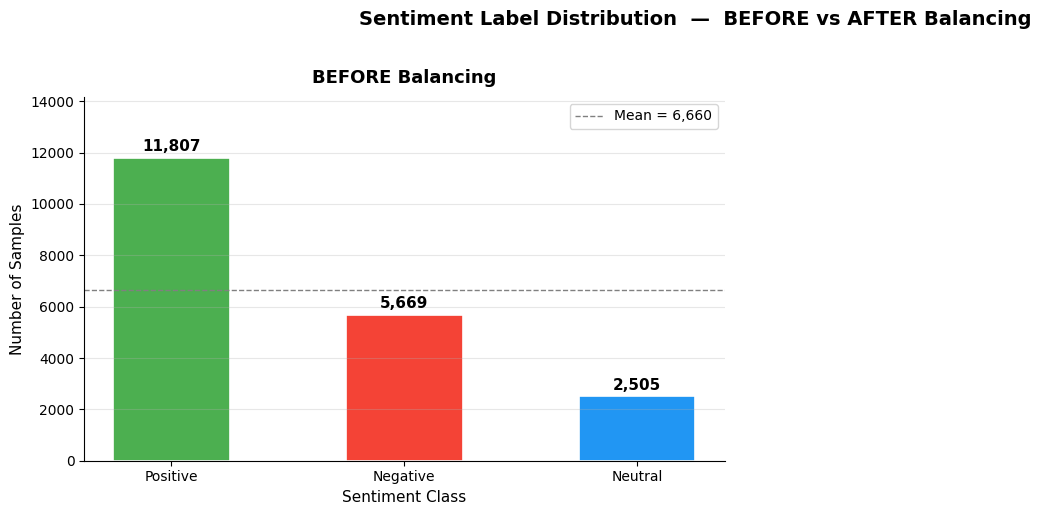

 Before-chart saved as before_balancing.png


In [24]:
#  BEFORE — Bar Chart 
CLASS_COLORS = {'Positive': '#4CAF50', 'Negative': '#F44336', 'Neutral': '#2196F3'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Label Distribution  —  BEFORE vs AFTER Balancing',
             fontsize=14, fontweight='bold', y=1.02)

# ---------- before ----------
ax = axes[0]
bars = ax.bar(
    counts_before.index,
    counts_before.values,
    color=[CLASS_COLORS.get(c, '#9E9E9E') for c in counts_before.index],
    edgecolor='white', linewidth=1.2, width=0.5
)
ax.set_title('BEFORE Balancing', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Sentiment Class', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_ylim(0, counts_before.max() * 1.20)
ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, counts_before.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.axhline(counts_before.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Mean = {counts_before.mean():,.0f}')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)


# axes[1] will be populated after balancing
axes[1].set_visible(False)

plt.tight_layout()
plt.savefig('before_balancing.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Before-chart saved as before_balancing.png')

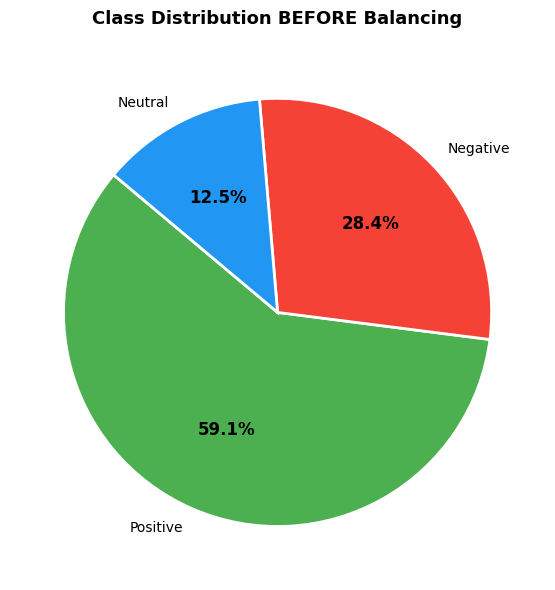

In [25]:
#  BEFORE — Pie Chart 
fig_pie, ax_pie = plt.subplots(figsize=(6, 6))
wedge_colors = [CLASS_COLORS.get(c, '#9E9E9E') for c in counts_before.index]
wedges, texts, autotexts = ax_pie.pie(
    counts_before.values,
    labels=counts_before.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
ax_pie.set_title('Class Distribution BEFORE Balancing', fontsize=13,
                 fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('before_pie.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Fix Imbalance 
#
#  PATH A  →  SMOTE on TF-IDF features  (if imbalanced-learn is installed)
#  PATH B  →  Random Oversampling via pandas  (always available)


TARGET_COUNT = counts_before.max()  

if SMOTE_AVAILABLE:
    #  PATH A : SMOTE 
    print('Running SMOTE on TF-IDF features …')

    # Drop rows where the text column is null
    df_smote = df.dropna(subset=[TEXT_COL]).copy()
    df_smote[TEXT_COL] = df_smote[TEXT_COL].astype(str)

    # TF-IDF vectorisation  (max 5 000 features for speed)
    tfidf = TfidfVectorizer(max_features=5000, strip_accents='unicode',
                            sublinear_tf=True, ngram_range=(1,2))
    X = tfidf.fit_transform(df_smote[TEXT_COL])
    y = df_smote[TARGET]

    sm = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)

    # We only need the labels (original feature space is lost after SMOTE)
    # Reconstruct a minimal balanced DataFrame
    df_balanced = pd.DataFrame({TARGET: y_res})

    # Attach original rows first, then mark synthetic rows
    n_orig = len(df_smote)
    df_balanced['is_synthetic'] = False
    df_balanced.loc[n_orig:, 'is_synthetic'] = True

    print(f'SMOTE complete. Synthetic samples added: {len(df_balanced) - n_orig:,}')

else:
    # ── PATH B : Random Oversampling (pandas) ────────────────────────────────
    print(f'Applying Random Oversampling …')
    print(f'Target count per class : {TARGET_COUNT:,}')
    print()

    balanced_parts = []
    for label, group in df.groupby(TARGET):
        n_have   = len(group)
        n_need   = TARGET_COUNT - n_have          # extra samples needed
        if n_need > 0:
            oversampled = group.sample(n=n_need, replace=True, random_state=42)
            oversampled['is_synthetic'] = True
            group = pd.concat([group, oversampled], ignore_index=True)
        else:
            group = group.copy()
        group['is_synthetic'] = group.get('is_synthetic', False).fillna(False)
        balanced_parts.append(group)
        print(f'  {label:<10}: {n_have:>6,} → {TARGET_COUNT:,}  '
              f'(+{n_need:,} synthetic)')

    df_balanced = pd.concat(balanced_parts, ignore_index=True)
    df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print()
print(f'Balanced dataset shape : {df_balanced.shape}')
print('Class distribution AFTER balancing:')
counts_after = df_balanced[TARGET].value_counts()
print(counts_after.to_string())

Running SMOTE on TF-IDF features …
SMOTE complete. Synthetic samples added: 15,432

Balanced dataset shape : (35409, 2)
Class distribution AFTER balancing:
sentiment_label
Positive    11803
Neutral     11803
Negative    11803


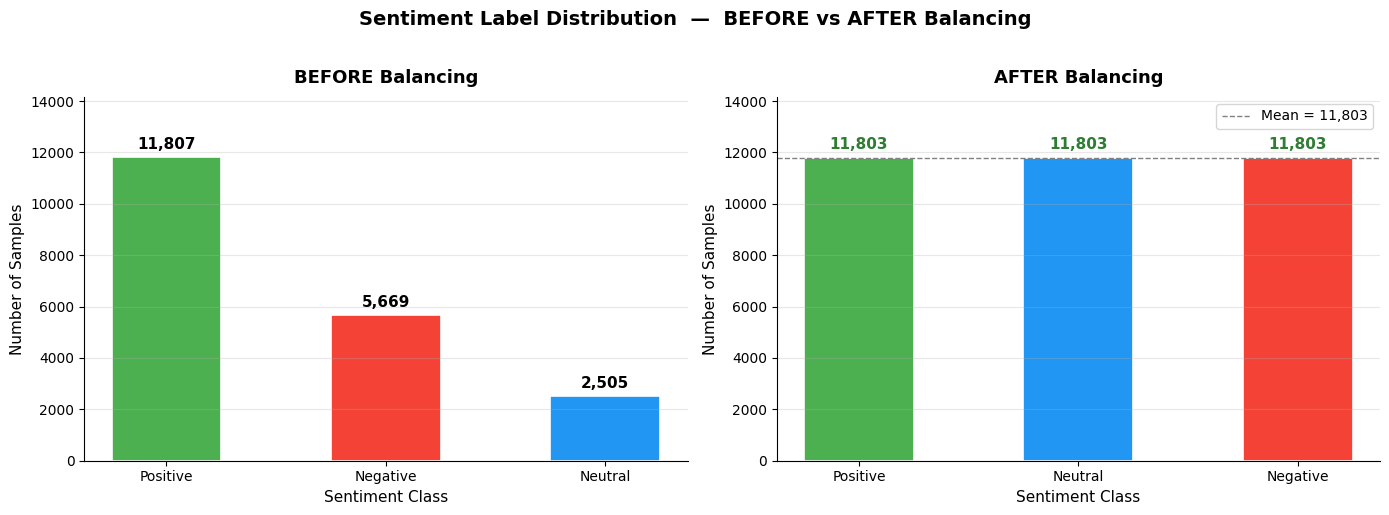

 Comparison bar chart saved as before_after_bar.png


In [27]:
# AFTER — Bar Chart 
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Sentiment Label Distribution  —  BEFORE vs AFTER Balancing',
              fontsize=14, fontweight='bold', y=1.02)

#  before (repeat for side-by-side) 
ax = axes2[0]
bars = ax.bar(
    counts_before.index,
    counts_before.values,
    color=[CLASS_COLORS.get(c, '#9E9E9E') for c in counts_before.index],
    edgecolor='white', linewidth=1.2, width=0.5
)
ax.set_title('BEFORE Balancing', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Sentiment Class', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_ylim(0, counts_after.max() * 1.20)
ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars, counts_before.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# after 
ax = axes2[1]
bars2 = ax.bar(
    counts_after.index,
    counts_after.values,
    color=[CLASS_COLORS.get(c, '#9E9E9E') for c in counts_after.index],
    edgecolor='white', linewidth=1.2, width=0.5
)
ax.set_title('AFTER Balancing', fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Sentiment Class', fontsize=11)
ax.set_ylabel('Number of Samples', fontsize=11)
ax.set_ylim(0, counts_after.max() * 1.20)
ax.spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, counts_after.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold',
            color='#2e7d32')
ax.axhline(counts_after.mean(), color='gray', linestyle='--', linewidth=1,
           label=f'Mean = {counts_after.mean():,.0f}')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('before_after_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Comparison bar chart saved as before_after_bar.png')

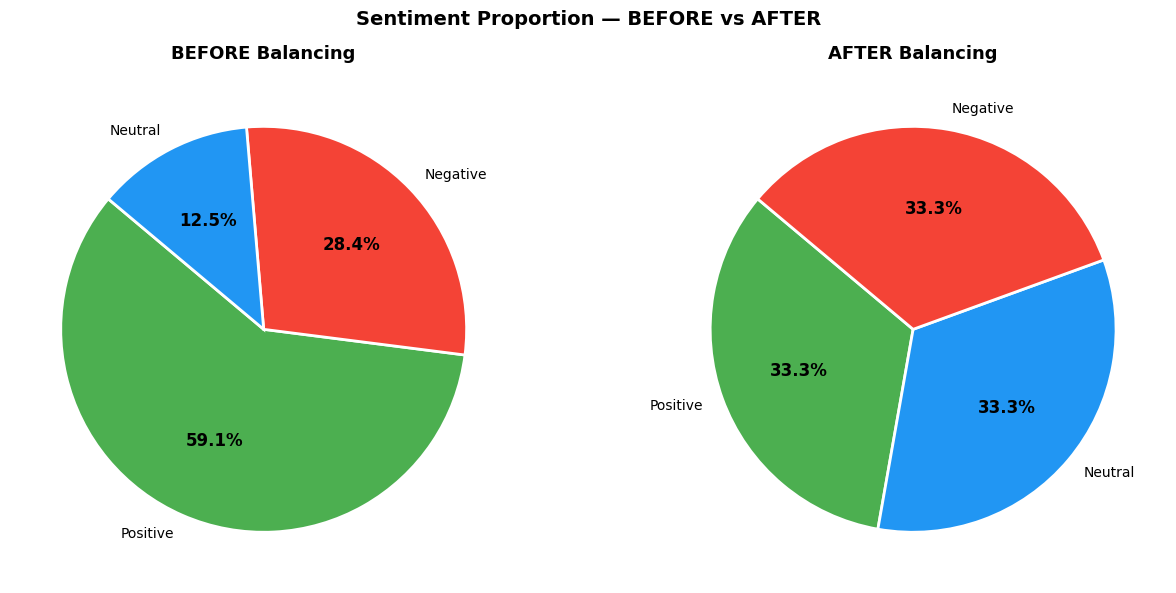

 Comparison pie chart saved as before_after_pie.png


In [28]:
#  Side-by-Side Pie Comparison 
fig3, axs = plt.subplots(1, 2, figsize=(13, 6))
fig3.suptitle('Sentiment Proportion — BEFORE vs AFTER', fontsize=14,
              fontweight='bold')

for ax, counts, title in zip(axs,
                              [counts_before, counts_after],
                              ['BEFORE Balancing', 'AFTER Balancing']):
    colors = [CLASS_COLORS.get(c, '#9E9E9E') for c in counts.index]
    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=140,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(12)
        at.set_fontweight('bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('before_after_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Comparison pie chart saved as before_after_pie.png')

In [29]:
#  Summary Statistics 
print('=' * 50)
print('         IMBALANCE SUMMARY')
print('=' * 50)
print(f'{"Class":<12} {"Before":>10} {"After":>10} {"Added":>10}')
print('-' * 50)
all_classes = counts_before.index.tolist()
for cls in all_classes:
    before = counts_before.get(cls, 0)
    after  = counts_after.get(cls, 0)
    added  = after - before
    print(f'{cls:<12} {before:>10,} {after:>10,} {added:>+10,}')
print('-' * 50)
print(f'{"TOTAL":<12} {counts_before.sum():>10,} {counts_after.sum():>10,}')
print('=' * 50)
imbalance_before = counts_before.max() / counts_before.min()
imbalance_after  = counts_after.max()  / counts_after.min()
print(f'Imbalance ratio BEFORE : {imbalance_before:.2f}x')
print(f'Imbalance ratio AFTER  : {imbalance_after:.2f}x')
print()
if imbalance_after == 1.0:
    print(' Dataset is now perfectly balanced!')
else:
    print('  Minor imbalance remains — check counts above.')

         IMBALANCE SUMMARY
Class            Before      After      Added
--------------------------------------------------
Positive         11,807     11,803         -4
Negative          5,669     11,803     +6,134
Neutral           2,505     11,803     +9,298
--------------------------------------------------
TOTAL            19,981     35,409
Imbalance ratio BEFORE : 4.71x
Imbalance ratio AFTER  : 1.00x

 Dataset is now perfectly balanced!
